In [2]:
# Clone the files into this new tab's session
# !git clone https://github.com/aidanGoesch/HumanEmbedding

# Move into the directory so Python can find the 'models' folder
# %cd HumanEmbedding

!pip install torch torchvision transformers scipy pillow matplotlib qwen_vl_utils

!pip install -U bitsandbytes>=0.46.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 1.5 MB/s eta 0:00:0000:0100:02m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 2.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 1.3 MB/s eta 0:00:0000:0100:01m
  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_arm64.whl (22.4 MB)
  Using cached pillow-12.2.0-cp310-cp310-macosx_11_0_arm64.whl (4.7 MB)
  Using cached matplotlib-3.10.9-cp310-cp310-macosx_11_0_arm64.whl (8.2 MB)
  Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 4.2 MB/s eta 0:00:00a 0:00:01
  Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.2 MB/s eta 0:00:00
  Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
  Using cached numpy-2.2.6-cp310-cp310-macosx_14_0_arm64.whl (5.3 MB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl (3.0 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.spatial.distance import pdist, squareform

from models.resnet_embedder import ResNetEmbedder
from models.clip_embedder import CLIPEmbedder
from models.vlm_embedder import VLMEmbedder

In [5]:
STIMULI_DIR = "stimuli/gw"
VALID_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

stimulus_paths = sorted(
    p for p in glob.glob(os.path.join(STIMULI_DIR, "*"))
    if p.lower().endswith(VALID_EXTS)
)
stimulus_names = [os.path.splitext(os.path.basename(p))[0] for p in stimulus_paths]
stimuli = {name: Image.open(p).convert("RGB") for name, p in zip(stimulus_names, stimulus_paths)}

print(f"Loaded {len(stimuli)} stimuli from {STIMULI_DIR}:")
print(stimulus_names)

Loaded 13 stimuli from stimuli/gw:
['buffalo', 'cactus', 'canoe', 'ferriswheel', 'fish', 'football', 'leaf', 'pool', 'potato', 'ship', 'skiis', 'train', 'tree']


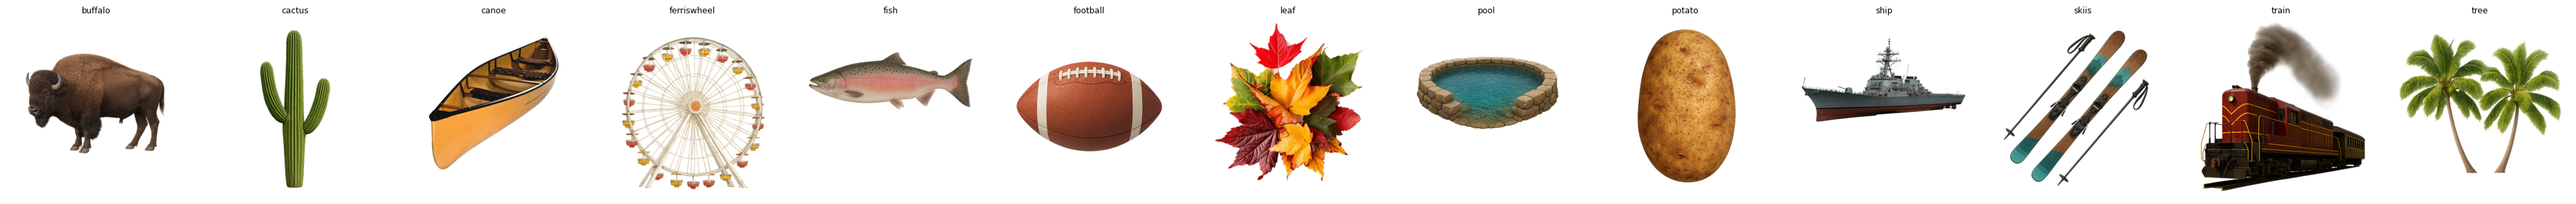

In [6]:
fig, axes = plt.subplots(1, len(stimuli), figsize=(3 * len(stimuli), 3))
if len(stimuli) == 1:
    axes = [axes]
for ax, name in zip(axes, stimulus_names):
    ax.imshow(stimuli[name])
    ax.set_title(name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
print("Loading ResNet...")
resnet_embedder = ResNetEmbedder()

print("Loading CLIP...")
clip_embedder = CLIPEmbedder()

print("Loading VLM...")
vlm_embedder = VLMEmbedder()

Loading ResNet...
using cpu


/Users/aidangoeschel/Documents/UCI/CCNL/HumanEmbedding/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/aidangoeschel/Documents/UCI/CCNL/HumanEmbedding/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/aidangoeschel/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [01:09<00:00, 1.47MB/s]


Loading CLIP...
using cpu


KeyboardInterrupt: 

In [ ]:
def to_numpy(embedding):
    """Flatten a torch.Tensor or np.ndarray embedding into a 1D numpy vector."""
    if hasattr(embedding, "detach"):
        embedding = embedding.detach().cpu().numpy()
    return np.asarray(embedding).reshape(-1)

In [ ]:
methods = {
    "ResNet": resnet_embedder,
    "CLIP": clip_embedder,
    "VLM": vlm_embedder,
}

embeddings = {method_name: {} for method_name in methods}

for method_name, embedder in methods.items():
    print(f"Embedding stimuli with {method_name}...")
    for name in stimulus_names:
        vec = embedder.get_embedding(stimuli[name])
        embeddings[method_name][name] = to_numpy(vec)

In [ ]:
FEATURE_PROMPT = "Describe this image."

embeddings["VLM-text"] = {}
for name in stimulus_names:
    vec = vlm_embedder.get_text_embedding(stimuli[name], FEATURE_PROMPT)
    embeddings["VLM-text"][name] = to_numpy(vec)

In [ ]:
def compute_rdm(embeddings_dict, names, metric="correlation"):
    """
    Build a representational dissimilarity matrix (RDM).

    Args:
        embeddings_dict: dict mapping stimulus name -> 1D embedding vector
        names: ordered list of stimulus names (defines row/col order)
        metric: distance metric passed to scipy.spatial.distance.pdist
            (e.g. "correlation", "cosine", "euclidean")

    Returns:
        np.ndarray of shape (n, n) — the RDM
    """
    matrix = np.stack([embeddings_dict[name] for name in names])
    distances = pdist(matrix, metric=metric)
    return squareform(distances)

In [ ]:
RDM_METRIC = "correlation"  # also try "cosine" or "euclidean"

rdms = {
    method_name: compute_rdm(embeddings[method_name], stimulus_names, metric=RDM_METRIC)
    for method_name in embeddings
}

In [ ]:
fig, axes = plt.subplots(1, len(rdms), figsize=(6 * len(rdms), 5))
if len(rdms) == 1:
    axes = [axes]

for ax, (method_name, rdm) in zip(axes, rdms.items()):
    im = ax.imshow(rdm, cmap="viridis")
    ax.set_xticks(range(len(stimulus_names)))
    ax.set_yticks(range(len(stimulus_names)))
    ax.set_xticklabels(stimulus_names, rotation=90, fontsize=8)
    ax.set_yticklabels(stimulus_names, fontsize=8)
    ax.set_title(f"{method_name} RDM", fontsize=12, fontweight="bold")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Scree Plots

In [ ]:
methods = {
    "ResNet": resnet_embedder,
    "CLIP": clip_embedder,
    "VLM": vlm_embedder,
}

embeddings = {method_name: {} for method_name in methods}

for method_name, embedder in methods.items():
    print(f"Embedding stimuli with {method_name}...")
    for name in stimulus_names:
        vec = embedder.get_embedding(stimuli[name])
        embeddings[method_name][name] = to_numpy(vec)

print("Done embedding all stimuli.")

In [ ]:
from sklearn.decomposition import PCA

def compute_scree(embeddings_dict, names):
    """
    Run PCA on a set of embeddings and return explained variance ratios
    per component, for a scree plot.

    Args:
        embeddings_dict: dict mapping stimulus name -> 1D embedding vector
        names: ordered list of stimulus names

    Returns:
        explained_variance_ratio: np.ndarray of shape (n_components,)
        cumulative_variance: np.ndarray of shape (n_components,)
    """
    matrix = np.stack([embeddings_dict[name] for name in names])  # (n_stimuli, n_features)

    # PCA rank is bounded by min(n_samples, n_features) - 1 (after centering)
    n_components = min(matrix.shape[0], matrix.shape[1]) - 1
    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(matrix)

    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)

    return explained_variance_ratio, cumulative_variance

In [ ]:
scree_data = {
    method_name: compute_scree(embeddings[method_name], stimulus_names)
    for method_name in embeddings
}

In [ ]:
fig, axes = plt.subplots(1, len(scree_data), figsize=(6 * len(scree_data), 5))
if len(scree_data) == 1:
    axes = [axes]

for ax, (method_name, (explained_var, cumulative_var)) in zip(axes, scree_data.items()):
    components = np.arange(1, len(explained_var) + 1)

    ax.plot(components, explained_var, marker="o", label="Explained variance")
    ax.plot(components, cumulative_var, marker="s", linestyle="--", label="Cumulative variance")

    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Variance Ratio")
    ax.set_title(f"{method_name} Scree Plot", fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Testing Different Axes

In [ ]:
# Each entry is conditioned into the prompt: "Describe the image in terms of {axis}."
# Add/remove axes here to test different attention targets.
FEATURE_AXES = [
    "size",
    "color",
    "shape",
    "texture",
    "living vs non-living",
    "material",
    "emotional tone",
    "function or purpose",
]

PROMPT_TEMPLATE = "Describe the image in terms of {axis}."

In [ ]:
vlm_axis_embeddings = {axis: {} for axis in FEATURE_AXES}

for axis in FEATURE_AXES:
    prompt = PROMPT_TEMPLATE.format(axis=axis)
    print(f"Embedding stimuli for axis: '{axis}'...")
    for name in stimulus_names:
        vec = vlm_embedder.get_text_embedding(stimuli[name], prompt)
        vlm_axis_embeddings[axis][name] = to_numpy(vec)

print("Done embedding all axes.")

In [ ]:
axis_scree_data = {
    axis: compute_scree(vlm_axis_embeddings[axis], stimulus_names)
    for axis in FEATURE_AXES
}

In [ ]:
n_axes = len(FEATURE_AXES)
n_cols = min(4, n_axes)
n_rows = int(np.ceil(n_axes / n_cols))

fig, axes_grid = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes_grid = np.atleast_1d(axes_grid).flatten()

for ax, axis_name in zip(axes_grid, FEATURE_AXES):
    explained_var, cumulative_var = axis_scree_data[axis_name]
    components = np.arange(1, len(explained_var) + 1)

    ax.plot(components, explained_var, marker="o", label="Explained variance")
    ax.plot(components, cumulative_var, marker="s", linestyle="--", label="Cumulative variance")

    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Variance Ratio")
    ax.set_title(f"VLM — '{axis_name}'", fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Hide any unused subplot slots
for ax in axes_grid[n_axes:]:
    ax.axis("off")

plt.tight_layout()
plt.show()